# Étape 1


## Installer les bibliothèques

In [20]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

import joblib

import warnings
warnings.filterwarnings("ignore")

# Étape 2

## Charger les 4 fichiers

In [2]:
customers = pd.read_csv("../data/raw/customers_data.csv")
marketing = pd.read_csv("../data/raw/marketing_data.csv")
products = pd.read_csv("../data/raw/products_data.csv")
sales = pd.read_csv("../data/raw/sales_data.csv")

In [3]:
print("Customers :", customers.shape)
print("Marketing :", marketing.shape)
print("Products  :", products.shape)
print("Sales     :", sales.shape)

Customers : (5, 7)
Marketing : (5, 8)
Products  : (5, 5)
Sales     : (5, 7)


In [4]:
display(customers.head())
display(marketing.head())
display(products.head())
display(sales.head())

,Customer_ID,Name,Age,Gender,Location,Join_Date,Total_Spent
0,2001,Alice,28,Female,New York,2022-05-10,500.0
1,2002,Bob,35,Male,Los Angeles,2022-06-15,750.0
2,2003,Charlie,22,Male,Chicago,2022-07-20,300.0
3,2004,Diana,30,Female,Houston,2022-08-25,600.0
4,2005,Eva,27,Female,Phoenix,2022-09-30,450.0


,Campaign_ID,Channel,Start_Date,End_Date,Budget,Impressions,Clicks,Conversions
0,1,Online,2023-01-01,2023-01-15,1000.0,50000,2000,150
1,2,In-Store,2023-01-10,2023-01-20,1500.0,30000,500,100
2,3,Social,2023-01-15,2023-01-25,2000.0,40000,1500,200
3,4,Email,2023-01-05,2023-01-15,500.0,20000,1000,50
4,5,TV,2023-01-01,2023-01-31,3000.0,60000,3000,250


,Product_ID,Product_Name,Category,Price,Brand
0,101,T-shirt,Clothing,25.0,Brand A
1,102,Jeans,Clothing,75.0,Brand B
2,103,Sneakers,Footwear,30.0,Brand C
3,104,Jacket,Outerwear,120.0,Brand D
4,105,Hat,Accessories,22.5,Brand E


,Sale_ID,Product_ID,Customer_ID,Date,Quantity,Sale_Price,Channel
0,1,101,2001,2023-01-15,2,50.0,Online
1,2,102,2002,2023-01-16,1,75.0,In-Store
2,3,103,2001,2023-01-17,3,30.0,Online
3,4,104,2003,2023-01-18,1,120.0,In-Store
4,5,105,2004,2023-01-19,2,45.0,Online


In [5]:
print("CUSTOMERS")
print(customers.columns.tolist())

print("\nMARKETING")
print(marketing.columns.tolist())

print("\nPRODUCTS")
print(products.columns.tolist())

print("\nSALES")
print(sales.columns.tolist())

CUSTOMERS
['Customer_ID', 'Name', 'Age', 'Gender', 'Location', 'Join_Date', 'Total_Spent']

MARKETING
['Campaign_ID', 'Channel', 'Start_Date', 'End_Date', 'Budget', 'Impressions', 'Clicks', 'Conversions']

PRODUCTS
['Product_ID', 'Product_Name', 'Category', 'Price', 'Brand']

SALES
['Sale_ID', 'Product_ID', 'Customer_ID', 'Date', 'Quantity', 'Sale_Price', 'Channel']


In [6]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Customer_ID  5 non-null      int64  
 1   Name         5 non-null      str    
 2   Age          5 non-null      int64  
 3   Gender       5 non-null      str    
 4   Location     5 non-null      str    
 5   Join_Date    5 non-null      str    
 6   Total_Spent  5 non-null      float64
dtypes: float64(1), int64(2), str(4)
memory usage: 551.0 bytes


In [7]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Sale_ID      5 non-null      int64  
 1   Product_ID   5 non-null      int64  
 2   Customer_ID  5 non-null      int64  
 3   Date         5 non-null      str    
 4   Quantity     5 non-null      int64  
 5   Sale_Price   5 non-null      float64
 6   Channel      5 non-null      str    
dtypes: float64(1), int64(4), str(2)
memory usage: 496.0 bytes


## Convertir les dates

In [9]:
# Conversion des dates
customers["Join_Date"] = pd.to_datetime(customers["Join_Date"])
sales["Date"] = pd.to_datetime(sales["Date"])

marketing["Start_Date"] = pd.to_datetime(marketing["Start_Date"])
marketing["End_Date"] = pd.to_datetime(marketing["End_Date"])

print("Dates converties avec succès.")

Dates converties avec succès.


In [10]:
print(customers.dtypes)
print(sales.dtypes)

Customer_ID             int64
Name                      str
Age                     int64
Gender                    str
Location                  str
Join_Date      datetime64[us]
Total_Spent           float64
dtype: object
Sale_ID                 int64
Product_ID              int64
Customer_ID             int64
Date           datetime64[us]
Quantity                int64
Sale_Price            float64
Channel                   str
dtype: object


## Vérifier les relations

In [11]:
print("Customer IDs dans customers :")
print(customers["Customer_ID"].unique())

print("\nCustomer IDs dans sales :")
print(sales["Customer_ID"].unique())

print("\nProduct IDs dans products :")
print(products["Product_ID"].unique())

print("\nProduct IDs dans sales :")
print(sales["Product_ID"].unique())

Customer IDs dans customers :
[2001 2002 2003 2004 2005]

Customer IDs dans sales :
[2001 2002 2003 2004]

Product IDs dans products :
[101 102 103 104 105]

Product IDs dans sales :
[101 102 103 104 105]


# Étape 3

## Joindre Sales + Products

In [13]:
sales_products = sales.merge(
    products,
    on="Product_ID",
    how="left"
)

In [14]:
display(sales_products)

,Sale_ID,Product_ID,Customer_ID,Date,Quantity,Sale_Price,Channel,Product_Name,Category,Price,Brand
0,1,101,2001,2023-01-15,2,50.0,Online,T-shirt,Clothing,25.0,Brand A
1,2,102,2002,2023-01-16,1,75.0,In-Store,Jeans,Clothing,75.0,Brand B
2,3,103,2001,2023-01-17,3,30.0,Online,Sneakers,Footwear,30.0,Brand C
3,4,104,2003,2023-01-18,1,120.0,In-Store,Jacket,Outerwear,120.0,Brand D
4,5,105,2004,2023-01-19,2,45.0,Online,Hat,Accessories,22.5,Brand E


## Calculer le montant de chaque vente

In [25]:
sales_products["Sale_Amount"] = (
    sales_products["Quantity"] * sales_products["Sale_Price"]
)

In [16]:
display(
    sales_products[
        [
            "Sale_ID",
            "Customer_ID",
            "Product_ID",
            "Quantity",
            "Sale_Price",
            "Sale_Amount"
        ]
    ]
)

,Sale_ID,Customer_ID,Product_ID,Quantity,Sale_Price,Sale_Amount
0,1,2001,101,2,50.0,100.0
1,2,2002,102,1,75.0,75.0
2,3,2001,103,3,30.0,90.0
3,4,2003,104,1,120.0,120.0
4,5,2004,105,2,45.0,90.0


## Construire les statistiques d'achat par client

In [26]:
sales_features = sales_products.groupby("Customer_ID").agg(
    Number_of_Purchases=("Sale_ID", "count"),
    Total_Quantity=("Quantity", "sum"),
    Sales_Total=("Sale_Amount", "sum"),
    Average_Sale=("Sale_Amount", "mean"),
    Last_Purchase_Date=("Date", "max"),
    First_Purchase_Date=("Date", "min")
).reset_index()

In [18]:
display(sales_features)

,Customer_ID,Number_of_Purchases,Total_Quantity,Sales_Total,Average_Sale,Last_Purchase_Date,First_Purchase_Date
0,2001,2,5,190.0,95.0,2023-01-17,2023-01-15
1,2002,1,1,75.0,75.0,2023-01-16,2023-01-16
2,2003,1,1,120.0,120.0,2023-01-18,2023-01-18
3,2004,1,2,90.0,90.0,2023-01-19,2023-01-19


## Calculer la récence

In [33]:
reference_date = sales["Date"].max()

print("Date de référence :", reference_date)

Date de référence : 2023-01-19 00:00:00


In [34]:
sales_features["Recency"] = (
    reference_date - sales_features["Last_Purchase_Date"]
).dt.days

In [35]:
display(
    sales_features[
        [
            "Customer_ID",
            "Number_of_Purchases",
            "Sales_Total",
            "Average_Sale",
            "Recency"
        ]
    ]
)

,Customer_ID,Number_of_Purchases,Sales_Total,Average_Sale,Recency
0,2001,2,190.0,95.0,2
1,2002,1,75.0,75.0,3
2,2003,1,120.0,120.0,1
3,2004,1,90.0,90.0,0


## Fusionner avec Customers

In [36]:
customer_data = customers.merge(
    sales_features,
    on="Customer_ID",
    how="left"
)

## Gérer les clients sans achat

In [37]:
purchase_columns = [
    "Number_of_Purchases",
    "Total_Quantity",
    "Sales_Total",
    "Average_Sale"
]

customer_data[purchase_columns] = (
    customer_data[purchase_columns]
    .fillna(0)
)

In [38]:
customer_data["Recency"] = customer_data["Recency"].fillna(
    (reference_date - customer_data["Join_Date"]).dt.days
)

## dataset final

In [39]:
display(customer_data)

,Customer_ID,Name,Age,Gender,Location,Join_Date,Total_Spent,Number_of_Purchases,Total_Quantity,Sales_Total,Average_Sale,Last_Purchase_Date,First_Purchase_Date,Recency
0,2001,Alice,28,Female,New York,2022-05-10,500.0,2.0,5.0,190.0,95.0,2023-01-17,2023-01-15,2.0
1,2002,Bob,35,Male,Los Angeles,2022-06-15,750.0,1.0,1.0,75.0,75.0,2023-01-16,2023-01-16,3.0
2,2003,Charlie,22,Male,Chicago,2022-07-20,300.0,1.0,1.0,120.0,120.0,2023-01-18,2023-01-18,1.0
3,2004,Diana,30,Female,Houston,2022-08-25,600.0,1.0,2.0,90.0,90.0,2023-01-19,2023-01-19,0.0
4,2005,Eva,27,Female,Phoenix,2022-09-30,450.0,0.0,0.0,0.0,0.0,NaT,NaT,111.0


# Étape 4

# Vérifier notre dataset

In [43]:
print("Dimensions du dataset :", customer_data.shape)

print("\nColonnes disponibles :")
print(customer_data.columns.tolist())

print("\nNombre de valeurs manquantes :")
print(customer_data.isnull().sum())

Dimensions du dataset : (5, 14)

Colonnes disponibles :
['Customer_ID', 'Name', 'Age', 'Gender', 'Location', 'Join_Date', 'Total_Spent', 'Number_of_Purchases', 'Total_Quantity', 'Sales_Total', 'Average_Sale', 'Last_Purchase_Date', 'First_Purchase_Date', 'Recency']

Nombre de valeurs manquantes :
Customer_ID            0
Name                   0
Age                    0
Gender                 0
Location               0
Join_Date              0
Total_Spent            0
Number_of_Purchases    0
Total_Quantity         0
Sales_Total            0
Average_Sale           0
Last_Purchase_Date     1
First_Purchase_Date    1
Recency                0
dtype: int64


In [44]:
display(customer_data)

,Customer_ID,Name,Age,Gender,Location,Join_Date,Total_Spent,Number_of_Purchases,Total_Quantity,Sales_Total,Average_Sale,Last_Purchase_Date,First_Purchase_Date,Recency
0,2001,Alice,28,Female,New York,2022-05-10,500.0,2.0,5.0,190.0,95.0,2023-01-17,2023-01-15,2.0
1,2002,Bob,35,Male,Los Angeles,2022-06-15,750.0,1.0,1.0,75.0,75.0,2023-01-16,2023-01-16,3.0
2,2003,Charlie,22,Male,Chicago,2022-07-20,300.0,1.0,1.0,120.0,120.0,2023-01-18,2023-01-18,1.0
3,2004,Diana,30,Female,Houston,2022-08-25,600.0,1.0,2.0,90.0,90.0,2023-01-19,2023-01-19,0.0
4,2005,Eva,27,Female,Phoenix,2022-09-30,450.0,0.0,0.0,0.0,0.0,NaT,NaT,111.0


## Vérifier la récence

In [45]:
print("Statistiques de Recency :")
print(customer_data["Recency"].describe())

Statistiques de Recency :
count      5.00000
mean      23.40000
std       48.98265
min        0.00000
25%        1.00000
50%        2.00000
75%        3.00000
max      111.00000
Name: Recency, dtype: float64


In [46]:
display(
    customer_data[
        [
            "Customer_ID",
            "Name",
            "Recency",
            "Number_of_Purchases",
            "Sales_Total"
        ]
    ].sort_values("Recency")
)

,Customer_ID,Name,Recency,Number_of_Purchases,Sales_Total
3,2004,Diana,0.0,1.0,90.0
2,2003,Charlie,1.0,1.0,120.0
0,2001,Alice,2.0,2.0,190.0
1,2002,Bob,3.0,1.0,75.0
4,2005,Eva,111.0,0.0,0.0


In [47]:
customer_data["Churn"] = (
    customer_data["Recency"] > 90
).astype(int)

## Créer Churn_Demo

In [48]:
customer_data["Has_Purchase"] = (
    customer_data["Number_of_Purchases"] > 0
).astype(int)

In [49]:
display(
    customer_data[
        [
            "Customer_ID",
            "Name",
            "Number_of_Purchases",
            "Sales_Total",
            "Has_Purchase"
        ]
    ]
)

,Customer_ID,Name,Number_of_Purchases,Sales_Total,Has_Purchase
0,2001,Alice,2.0,190.0,1
1,2002,Bob,1.0,75.0,1
2,2003,Charlie,1.0,120.0,1
3,2004,Diana,1.0,90.0,1
4,2005,Eva,0.0,0.0,0


## Définir une règle de démonstration


In [50]:
customer_data["Churn_Demo"] = (
    customer_data["Has_Purchase"] == 0
).astype(int)

In [51]:
display(
    customer_data[
        [
            "Customer_ID",
            "Name",
            "Number_of_Purchases",
            "Sales_Total",
            "Has_Purchase",
            "Churn_Demo"
        ]
    ]
)

,Customer_ID,Name,Number_of_Purchases,Sales_Total,Has_Purchase,Churn_Demo
0,2001,Alice,2.0,190.0,1,0
1,2002,Bob,1.0,75.0,1,0
2,2003,Charlie,1.0,120.0,1,0
3,2004,Diana,1.0,90.0,1,0
4,2005,Eva,0.0,0.0,0,1


## Vérifier la distribution

In [52]:
print(
    customer_data["Churn_Demo"].value_counts()
)

Churn_Demo
0    4
1    1
Name: count, dtype: int64


In [53]:
print(
    customer_data["Churn_Demo"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Churn_Demo
0    80.0
1    20.0
Name: proportion, dtype: float64


## Visualiser

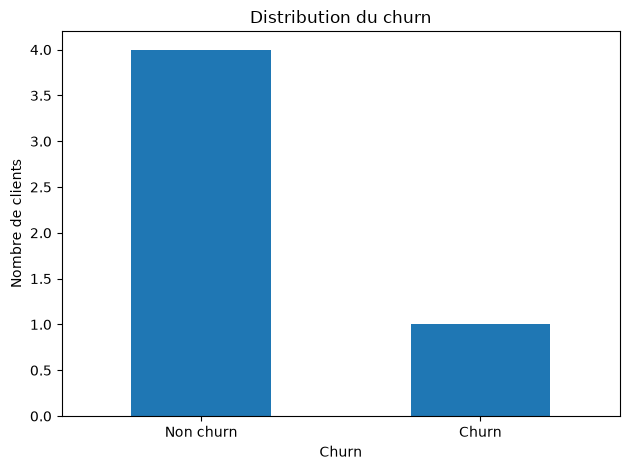

In [54]:
customer_data["Churn_Demo"].value_counts().plot(
    kind="bar"
)

plt.title("Distribution du churn")
plt.xlabel("Churn")
plt.ylabel("Nombre de clients")
plt.xticks(
    [0, 1],
    ["Non churn", "Churn"],
    rotation=0
)

plt.tight_layout()
plt.show()

## Créer le dataset

In [55]:
features = [
    "Age",
    "Total_Spent",
    "Recency",
    "Sales_Total",
    "Average_Sale",
    "Total_Quantity"
]

## Construire X et y

In [56]:
X = customer_data[features].copy()

y = customer_data["Churn_Demo"].copy()

In [58]:
print("X :")
display(X)

print("\ny :")
display(y)

X :


,Age,Total_Spent,Recency,Sales_Total,Average_Sale,Total_Quantity
0,28,500.0,2.0,190.0,95.0,5.0
1,35,750.0,3.0,75.0,75.0,1.0
2,22,300.0,1.0,120.0,120.0,1.0
3,30,600.0,0.0,90.0,90.0,2.0
4,27,450.0,111.0,0.0,0.0,0.0



y :


0    0
1    0
2    0
3    0
4    1
Name: Churn_Demo, dtype: int64

## Vérifier les valeurs manquantes

In [59]:
print("Valeurs manquantes dans X :")
print(X.isnull().sum())

Valeurs manquantes dans X :
Age               0
Total_Spent       0
Recency           0
Sales_Total       0
Average_Sale      0
Total_Quantity    0
dtype: int64


## Verifier les types

In [60]:
print(X.dtypes)
print("\nType de y :", y.dtype)

Age                 int64
Total_Spent       float64
Recency           float64
Sales_Total       float64
Average_Sale      float64
Total_Quantity    float64
dtype: object

Type de y : int64


## Vérifier X et y

In [61]:
print("Dimensions X :", X.shape)
print("Dimensions y :", y.shape)

print("\nDistribution de y :")
print(y.value_counts())

Dimensions X : (5, 6)
Dimensions y : (5,)

Distribution de y :
Churn_Demo
0    4
1    1
Name: count, dtype: int64


## le pipeline 

In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.4,
    random_state=42
)

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

Train : (3, 6)
Test  : (2, 6)


In [64]:
print("Classes train :", y_train.unique())
print("Classes test  :", y_test.unique())

Classes train : [0]
Classes test  : [0 1]


## code complet

In [65]:

print("=" * 60)
print("M6 - CREATION DE LA VARIABLE CHURN")
print("=" * 60)

# ------------------------------------------------------------
# 1. Vérification du dataset
# ------------------------------------------------------------

print("\nDimensions du dataset :", customer_data.shape)

# ------------------------------------------------------------
# 2. Vérification de l'activité d'achat
# ------------------------------------------------------------

customer_data["Has_Purchase"] = (
    customer_data["Number_of_Purchases"] > 0
).astype(int)

# ------------------------------------------------------------
# 3. Création de la cible de démonstration
# ------------------------------------------------------------
# ATTENTION :
# Cette variable est uniquement destinée au prototype.
# Pour un vrai modèle, le churn doit être défini sur une
# période future indépendante de la période d'observation.

customer_data["Churn_Demo"] = (
    customer_data["Has_Purchase"] == 0
).astype(int)

# ------------------------------------------------------------
# 4. Affichage du résultat
# ------------------------------------------------------------

print("\nClients et churn :")

display(
    customer_data[
        [
            "Customer_ID",
            "Name",
            "Number_of_Purchases",
            "Sales_Total",
            "Recency",
            "Has_Purchase",
            "Churn_Demo"
        ]
    ]
)

# ------------------------------------------------------------
# 5. Distribution du churn
# ------------------------------------------------------------

print("\nDistribution du churn :")
print(customer_data["Churn_Demo"].value_counts())

print("\nPourcentage :")
print(
    customer_data["Churn_Demo"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

# ------------------------------------------------------------
# 6. Variables explicatives
# ------------------------------------------------------------

features = [
    "Age",
    "Total_Spent",
    "Recency",
    "Sales_Total",
    "Average_Sale",
    "Total_Quantity"
]

X = customer_data[features].copy()
y = customer_data["Churn_Demo"].copy()

# ------------------------------------------------------------
# 7. Vérification des données
# ------------------------------------------------------------

print("\nDimensions X :", X.shape)
print("Dimensions y :", y.shape)

print("\nValeurs manquantes :")
print(X.isnull().sum())

print("\nTypes :")
print(X.dtypes)

# ------------------------------------------------------------
# 8. Résumé
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("ETAPE 4 TERMINEE")
print("=" * 60)

print("Nombre de clients :", len(customer_data))
print("Nombre de variables :", len(features))
print("Nombre de non-churn :", (y == 0).sum())
print("Nombre de churn :", (y == 1).sum())

print("\nVariables utilisées :")
for feature in features:
    print(" -", feature)

M6 - CREATION DE LA VARIABLE CHURN

Dimensions du dataset : (5, 17)

Clients et churn :


,Customer_ID,Name,Number_of_Purchases,Sales_Total,Recency,Has_Purchase,Churn_Demo
0,2001,Alice,2.0,190.0,2.0,1,0
1,2002,Bob,1.0,75.0,3.0,1,0
2,2003,Charlie,1.0,120.0,1.0,1,0
3,2004,Diana,1.0,90.0,0.0,1,0
4,2005,Eva,0.0,0.0,111.0,0,1



Distribution du churn :
Churn_Demo
0    4
1    1
Name: count, dtype: int64

Pourcentage :
Churn_Demo
0    80.0
1    20.0
Name: proportion, dtype: float64

Dimensions X : (5, 6)
Dimensions y : (5,)

Valeurs manquantes :
Age               0
Total_Spent       0
Recency           0
Sales_Total       0
Average_Sale      0
Total_Quantity    0
dtype: int64

Types :
Age                 int64
Total_Spent       float64
Recency           float64
Sales_Total       float64
Average_Sale      float64
Total_Quantity    float64
dtype: object

ETAPE 4 TERMINEE
Nombre de clients : 5
Nombre de variables : 6
Nombre de non-churn : 4
Nombre de churn : 1

Variables utilisées :
 - Age
 - Total_Spent
 - Recency
 - Sales_Total
 - Average_Sale
 - Total_Quantity


In [66]:
print(y.value_counts())
display(
    customer_data[
        [
            "Customer_ID",
            "Name",
            "Recency",
            "Number_of_Purchases",
            "Sales_Total",
            "Churn_Demo"
        ]
    ]
)

Churn_Demo
0    4
1    1
Name: count, dtype: int64


,Customer_ID,Name,Recency,Number_of_Purchases,Sales_Total,Churn_Demo
0,2001,Alice,2.0,2.0,190.0,0
1,2002,Bob,3.0,1.0,75.0,0
2,2003,Charlie,1.0,1.0,120.0,0
3,2004,Diana,0.0,1.0,90.0,0
4,2005,Eva,111.0,0.0,0.0,1


# Etape 5

## Préparer les données

In [67]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

print("=" * 60)
print("M6 - REGRESSION LOGISTIQUE")
print("=" * 60)

# Variables explicatives
X = customer_data[features].copy()

# Variable cible
y = customer_data["Churn_Demo"].copy()

print("\nDimensions X :", X.shape)
print("Dimensions y :", y.shape)

print("\nDistribution de la cible :")
print(y.value_counts())

M6 - REGRESSION LOGISTIQUE

Dimensions X : (5, 6)
Dimensions y : (5,)

Distribution de la cible :
Churn_Demo
0    4
1    1
Name: count, dtype: int64


## Vérifier les classes


In [68]:
if y.nunique() < 2:
    raise ValueError(
        "La variable cible doit contenir au moins deux classes."
    )

print("Nombre de classes :", y.nunique())
print("Classes :", sorted(y.unique()))

Nombre de classes : 2
Classes : [np.int64(0), np.int64(1)]


## Créer le modèle


In [69]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

In [70]:
logistic_model.fit(X, y)

print("Régression Logistique entraînée avec succès.")

Régression Logistique entraînée avec succès.


## Faire les prédictions

In [71]:
y_pred_lr = logistic_model.predict(X)

In [72]:
y_proba_lr = logistic_model.predict_proba(X)[:, 1]

In [73]:
prediction_lr = customer_data[
    [
        "Customer_ID",
        "Name"
    ]
].copy()

prediction_lr["Churn_Reel"] = y
prediction_lr["Prediction_Churn"] = y_pred_lr
prediction_lr["Probabilite_Churn"] = y_proba_lr

display(prediction_lr)

,Customer_ID,Name,Churn_Reel,Prediction_Churn,Probabilite_Churn
0,2001,Alice,0,0,0.026174
1,2002,Bob,0,0,0.077117
2,2003,Charlie,0,0,0.069840
3,2004,Diana,0,0,0.064838
4,2005,Eva,1,1,0.762099


## comprendre le probabilite 

In [74]:
def get_risk_level(probability):

    if probability >= 0.70:
        return "Élevé"

    elif probability >= 0.40:
        return "Moyen"

    else:
        return "Faible"

In [75]:
prediction_lr["Niveau_Risque"] = (
    prediction_lr["Probabilite_Churn"]
    .apply(get_risk_level)
)

display(prediction_lr)

,Customer_ID,Name,Churn_Reel,Prediction_Churn,Probabilite_Churn,Niveau_Risque
0,2001,Alice,0,0,0.026174,Faible
1,2002,Bob,0,0,0.077117,Faible
2,2003,Charlie,0,0,0.069840,Faible
3,2004,Diana,0,0,0.064838,Faible
4,2005,Eva,1,1,0.762099,Élevé


## Évaluation technique

In [76]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [77]:
accuracy_lr = accuracy_score(y, y_pred_lr)

precision_lr = precision_score(
    y,
    y_pred_lr,
    zero_division=0
)

recall_lr = recall_score(
    y,
    y_pred_lr,
    zero_division=0
)

f1_lr = f1_score(
    y,
    y_pred_lr,
    zero_division=0
)

In [78]:
print("=== REGRESSION LOGISTIQUE ===")

print(f"Accuracy  : {accuracy_lr:.4f}")
print(f"Precision : {precision_lr:.4f}")
print(f"Recall    : {recall_lr:.4f}")
print(f"F1-score  : {f1_lr:.4f}")

=== REGRESSION LOGISTIQUE ===
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1-score  : 1.0000


## Matrice de confusion

In [79]:
cm_lr = confusion_matrix(y, y_pred_lr)

print("Matrice de confusion :")
print(cm_lr)

Matrice de confusion :
[[4 0]
 [0 1]]


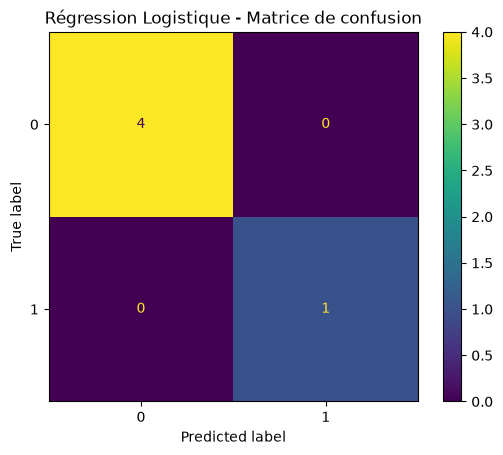

In [80]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y,
    y_pred_lr
)

plt.title("Régression Logistique - Matrice de confusion")
plt.show()

## Classification report

In [81]:
print(
    classification_report(
        y,
        y_pred_lr,
        target_names=[
            "Non Churn",
            "Churn"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

   Non Churn       1.00      1.00      1.00         4
       Churn       1.00      1.00      1.00         1

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



## ROC-AUC

In [82]:
from sklearn.metrics import roc_auc_score

roc_auc_lr = roc_auc_score(
    y,
    y_proba_lr
)

print(f"ROC-AUC : {roc_auc_lr:.4f}")

ROC-AUC : 1.0000


## Courbe ROC

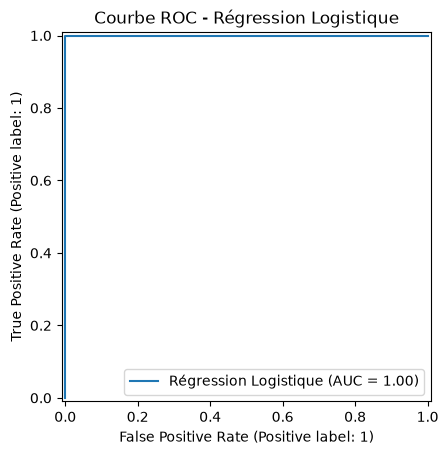

In [83]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y,
    y_proba_lr,
    name="Régression Logistique"
)

plt.title("Courbe ROC - Régression Logistique")
plt.show()

In [84]:
lr = logistic_model.named_steps["model"]

In [85]:
coefficients = pd.DataFrame({
    "Variable": features,
    "Coefficient": lr.coef_[0]
})

In [86]:
coefficients["Abs_Coefficient"] = (
    coefficients["Coefficient"].abs()
)

coefficients = coefficients.sort_values(
    "Abs_Coefficient",
    ascending=False
)

display(coefficients)

,Variable,Coefficient,Abs_Coefficient
2,Recency,0.594834,0.594834
4,Average_Sale,-0.552998,0.552998
3,Sales_Total,-0.403946,0.403946
5,Total_Quantity,-0.236600,0.236600
1,Total_Spent,-0.157362,0.157362
0,Age,-0.115382,0.115382


## Sauvegarder le modèle

In [87]:
import joblib

joblib.dump(
    logistic_model,
    "../models/logistic_churn.pkl"
)

print("Modèle sauvegardé : ../models/logistic_churn.pkl")

Modèle sauvegardé : ../models/logistic_churn.pkl


In [88]:
customer_data["Churn_Probability_LR"] = y_proba_lr

customer_data["Churn_Prediction_LR"] = y_pred_lr

In [89]:
display(
    customer_data[
        [
            "Customer_ID",
            "Name",
            "Recency",
            "Sales_Total",
            "Churn_Demo",
            "Churn_Probability_LR",
            "Churn_Prediction_LR"
        ]
    ]
)

,Customer_ID,Name,Recency,Sales_Total,Churn_Demo,Churn_Probability_LR,Churn_Prediction_LR
0,2001,Alice,2.0,190.0,0,0.026174,0
1,2002,Bob,3.0,75.0,0,0.077117,0
2,2003,Charlie,1.0,120.0,0,0.069840,0
3,2004,Diana,0.0,90.0,0,0.064838,0
4,2005,Eva,111.0,0.0,1,0.762099,1


# Étape 6


## Importer le modèle

In [91]:
from sklearn.ensemble import RandomForestClassifier

## Préparer X et y

In [92]:
features = [
    "Age",
    "Total_Spent",
    "Recency",
    "Sales_Total",
    "Average_Sale",
    "Total_Quantity"
]

X = customer_data[features].copy()
y = customer_data["Churn_Demo"].copy()

print("X :", X.shape)
print("y :", y.shape)

print("\nDistribution de la cible :")
print(y.value_counts())

X : (5, 6)
y : (5,)

Distribution de la cible :
Churn_Demo
0    4
1    1
Name: count, dtype: int64


## Créer le Random Forest

In [93]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=3,
    random_state=42,
    class_weight="balanced"
)

## Entraîner le modèle


In [94]:
rf_model.fit(X, y)

print("Random Forest entraîné avec succès.")

Random Forest entraîné avec succès.


## Faire les prédictions

In [95]:
y_pred_rf = rf_model.predict(X)

y_proba_rf = rf_model.predict_proba(X)[:, 1]

In [96]:
print("Prédictions :", y_pred_rf)
print("Probabilités :", y_proba_rf)

Prédictions : [0 0 0 0 1]
Probabilités : [0.13 0.06 0.22 0.09 0.98]


In [97]:
prediction_rf = customer_data[[
    "Customer_ID",
    "Name"
]].copy()

prediction_rf["Churn_Reel"] = y
prediction_rf["Prediction_Churn"] = y_pred_rf
prediction_rf["Probabilite_Churn"] = y_proba_rf

prediction_rf

,Customer_ID,Name,Churn_Reel,Prediction_Churn,Probabilite_Churn
0,2001,Alice,0,0,0.13
1,2002,Bob,0,0,0.06
2,2003,Charlie,0,0,0.22
3,2004,Diana,0,0,0.09
4,2005,Eva,1,1,0.98


In [98]:
def get_risk_level(probability):
    if probability >= 0.70:
        return "Élevé"
    elif probability >= 0.40:
        return "Moyen"
    else:
        return "Faible"

In [99]:
prediction_rf["Niveau_Risque"] = (
    prediction_rf["Probabilite_Churn"]
    .apply(get_risk_level)
)

prediction_rf

,Customer_ID,Name,Churn_Reel,Prediction_Churn,Probabilite_Churn,Niveau_Risque
0,2001,Alice,0,0,0.13,Faible
1,2002,Bob,0,0,0.06,Faible
2,2003,Charlie,0,0,0.22,Faible
3,2004,Diana,0,0,0.09,Faible
4,2005,Eva,1,1,0.98,Élevé


## Évaluer le Random Forest

In [100]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [101]:
accuracy_rf = accuracy_score(y, y_pred_rf)

precision_rf = precision_score(
    y,
    y_pred_rf,
    zero_division=0
)

recall_rf = recall_score(
    y,
    y_pred_rf,
    zero_division=0
)

f1_rf = f1_score(
    y,
    y_pred_rf,
    zero_division=0
)

roc_auc_rf = roc_auc_score(
    y,
    y_proba_rf
)

In [102]:
print("=== RANDOM FOREST ===")
print(f"Accuracy  : {accuracy_rf:.4f}")
print(f"Precision : {precision_rf:.4f}")
print(f"Recall    : {recall_rf:.4f}")
print(f"F1-score  : {f1_rf:.4f}")
print(f"ROC-AUC   : {roc_auc_rf:.4f}")

=== RANDOM FOREST ===
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1-score  : 1.0000
ROC-AUC   : 1.0000


## Matrice de confusion

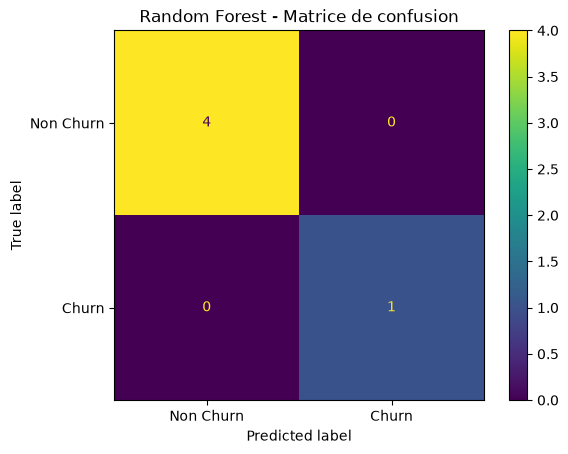

In [103]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y,
    y_pred_rf,
    display_labels=["Non Churn", "Churn"]
)

plt.title("Random Forest - Matrice de confusion")
plt.show()

## Classification Report

In [104]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y,
        y_pred_rf,
        target_names=["Non Churn", "Churn"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

   Non Churn       1.00      1.00      1.00         4
       Churn       1.00      1.00      1.00         1

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



## Courbe ROC

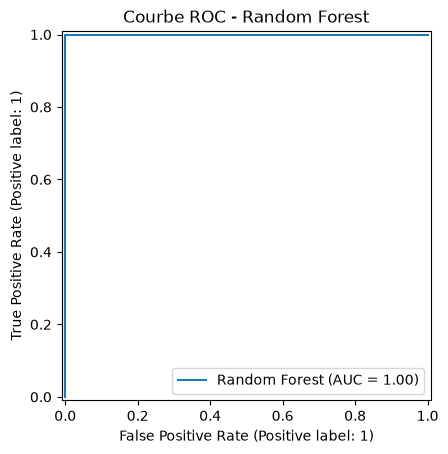

In [105]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y,
    y_proba_rf,
    name="Random Forest"
)

plt.title("Courbe ROC - Random Forest")
plt.show()

In [106]:
feature_importance = pd.DataFrame({
    "Variable": features,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

display(feature_importance)

,Variable,Importance
4,Average_Sale,0.212629
3,Sales_Total,0.206186
5,Total_Quantity,0.181701
2,Recency,0.154639
0,Age,0.127577
1,Total_Spent,0.117268


## Visualiser les importances

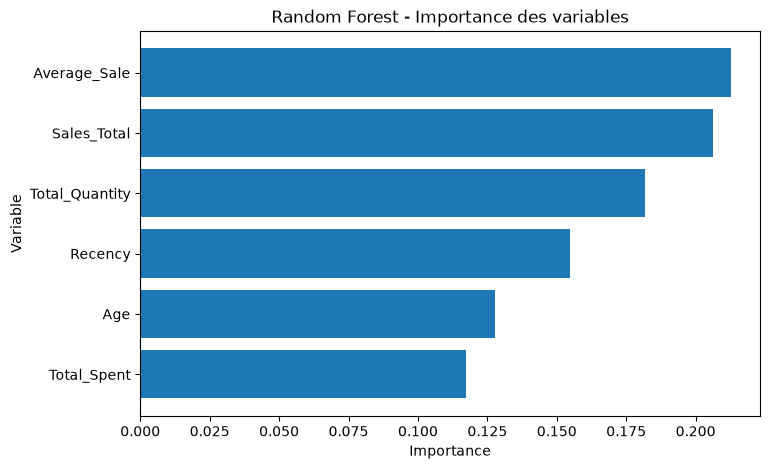

In [107]:
feature_importance_sorted = feature_importance.sort_values(
    "Importance"
)

plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance_sorted["Variable"],
    feature_importance_sorted["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Variable")
plt.title("Random Forest - Importance des variables")

plt.show()

In [108]:
customer_data["Churn_Probability_RF"] = y_proba_rf
customer_data["Churn_Prediction_RF"] = y_pred_rf

In [109]:
customer_data[[
    "Customer_ID",
    "Name",
    "Recency",
    "Sales_Total",
    "Churn_Demo",
    "Churn_Probability_RF",
    "Churn_Prediction_RF"
]]

,Customer_ID,Name,Recency,Sales_Total,Churn_Demo,Churn_Probability_RF,Churn_Prediction_RF
0,2001,Alice,2.0,190.0,0,0.13,0
1,2002,Bob,3.0,75.0,0,0.06,0
2,2003,Charlie,1.0,120.0,0,0.22,0
3,2004,Diana,0.0,90.0,0,0.09,0
4,2005,Eva,111.0,0.0,1,0.98,1


## Sauvegarder le modèle

In [110]:
import joblib

joblib.dump(
    rf_model,
    "../models/random_forest_churn.pkl"
)

print("Modèle sauvegardé : ../models/random_forest_churn.pkl")

Modèle sauvegardé : ../models/random_forest_churn.pkl


## faire la comparaison des deux modèles

In [111]:
comparison = pd.DataFrame({
    "Modèle": [
        "Régression Logistique",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_rf
    ],
    "Precision": [
        precision_lr,
        precision_rf
    ],
    "Recall": [
        recall_lr,
        recall_rf
    ],
    "F1-score": [
        f1_lr,
        f1_rf
    ],
    "ROC-AUC": [
        roc_auc_lr,
        roc_auc_rf
    ]
})

comparison

,Modèle,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Régression Logistique,1.0,1.0,1.0,1.0,1.0
1,Random Forest,1.0,1.0,1.0,1.0,1.0


# Etape 7

## Analyse comparative

In [113]:
print("=== COMPARAISON DES MODÈLES ===")
display(comparison.round(4))

=== COMPARAISON DES MODÈLES ===


,Modèle,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Régression Logistique,1.0,1.0,1.0,1.0,1.0
1,Random Forest,1.0,1.0,1.0,1.0,1.0


In [114]:
best_model = comparison.loc[
    comparison["F1-score"].idxmax(),
    "Modèle"
]

print("Meilleur modèle selon le F1-score :", best_model)

Meilleur modèle selon le F1-score : Régression Logistique


# Etape 8

## Comparer les variables importantes

In [115]:
lr_importance = coefficients[[
    "Variable",
    "Abs_Coefficient"
]].copy()

lr_importance = lr_importance.rename(
    columns={"Abs_Coefficient": "Logistic_Importance"}
)

rf_importance = feature_importance[[
    "Variable",
    "Importance"
]].copy()

rf_importance = rf_importance.rename(
    columns={"Importance": "RandomForest_Importance"}
)

importance_comparison = lr_importance.merge(
    rf_importance,
    on="Variable",
    how="inner"
)

importance_comparison = importance_comparison.sort_values(
    "Logistic_Importance",
    ascending=False
)

display(importance_comparison)

,Variable,Logistic_Importance,RandomForest_Importance
0,Recency,0.594834,0.154639
1,Average_Sale,0.552998,0.212629
2,Sales_Total,0.403946,0.206186
3,Total_Quantity,0.236600,0.181701
4,Total_Spent,0.157362,0.117268
5,Age,0.115382,0.127577


## Etape 9

## Identifier les clients à risque

In [116]:
risk_analysis = customer_data[[
    "Customer_ID",
    "Name",
    "Recency",
    "Sales_Total",
    "Total_Quantity",
    "Churn_Probability_LR",
    "Churn_Probability_RF"
]].copy()

risk_analysis["Risk_LR"] = (
    risk_analysis["Churn_Probability_LR"]
    .apply(get_risk_level)
)

risk_analysis["Risk_RF"] = (
    risk_analysis["Churn_Probability_RF"]
    .apply(get_risk_level)
)

risk_analysis

,Customer_ID,Name,Recency,Sales_Total,Total_Quantity,Churn_Probability_LR,Churn_Probability_RF,Risk_LR,Risk_RF
0,2001,Alice,2.0,190.0,5.0,0.026174,0.13,Faible,Faible
1,2002,Bob,3.0,75.0,1.0,0.077117,0.06,Faible,Faible
2,2003,Charlie,1.0,120.0,1.0,0.069840,0.22,Faible,Faible
3,2004,Diana,0.0,90.0,2.0,0.064838,0.09,Faible,Faible
4,2005,Eva,111.0,0.0,0.0,0.762099,0.98,Élevé,Élevé


## Trier les clients

In [117]:
risk_analysis = risk_analysis.sort_values(
    "Churn_Probability_RF",
    ascending=False
)

display(risk_analysis)

,Customer_ID,Name,Recency,Sales_Total,Total_Quantity,Churn_Probability_LR,Churn_Probability_RF,Risk_LR,Risk_RF
4,2005,Eva,111.0,0.0,0.0,0.762099,0.98,Élevé,Élevé
2,2003,Charlie,1.0,120.0,1.0,0.069840,0.22,Faible,Faible
0,2001,Alice,2.0,190.0,5.0,0.026174,0.13,Faible,Faible
3,2004,Diana,0.0,90.0,2.0,0.064838,0.09,Faible,Faible
1,2002,Bob,3.0,75.0,1.0,0.077117,0.06,Faible,Faible


## pourcentage

In [118]:
customer_data["Churn_Probability_LR_Pct"] = (
    customer_data["Churn_Probability_LR"] * 100
)

customer_data["Churn_Probability_RF_Pct"] = (
    customer_data["Churn_Probability_RF"] * 100
)

display(customer_data[[
    "Customer_ID",
    "Name",
    "Churn_Probability_LR_Pct",
    "Churn_Probability_RF_Pct"
]].round(2))

,Customer_ID,Name,Churn_Probability_LR_Pct,Churn_Probability_RF_Pct
0,2001,Alice,2.62,13.0
1,2002,Bob,7.71,6.0
2,2003,Charlie,6.98,22.0
3,2004,Diana,6.48,9.0
4,2005,Eva,76.21,98.0


## créer le score final


In [119]:
customer_data["Churn_Probability_Final"] = (
    customer_data["Churn_Probability_LR"] +
    customer_data["Churn_Probability_RF"]
) / 2

In [120]:
customer_data["Risk_Final"] = (
    customer_data["Churn_Probability_Final"]
    .apply(get_risk_level)
)

In [121]:
final_risk = customer_data[[
    "Customer_ID",
    "Name",
    "Recency",
    "Sales_Total",
    "Total_Quantity",
    "Churn_Probability_LR",
    "Churn_Probability_RF",
    "Churn_Probability_Final",
    "Risk_Final"
]].copy()

final_risk["Churn_Probability_Final"] *= 100

display(final_risk.round(2))

,Customer_ID,Name,Recency,Sales_Total,Total_Quantity,Churn_Probability_LR,Churn_Probability_RF,Churn_Probability_Final,Risk_Final
0,2001,Alice,2.0,190.0,5.0,0.03,0.13,7.81,Faible
1,2002,Bob,3.0,75.0,1.0,0.08,0.06,6.86,Faible
2,2003,Charlie,1.0,120.0,1.0,0.07,0.22,14.49,Faible
3,2004,Diana,0.0,90.0,2.0,0.06,0.09,7.74,Faible
4,2005,Eva,111.0,0.0,0.0,0.76,0.98,87.10,Élevé


# Étape 10

## Calcul du CLV

### Calculer la fréquence d'achat

In [125]:
customer_data["Customer_Age_Years"] = (
    (reference_date - customer_data["Join_Date"]).dt.days / 365
)

customer_data["Customer_Age_Years"] = (
    customer_data["Customer_Age_Years"].clip(lower=0.01)
)

customer_data["Purchase_Frequency"] = (
    customer_data["Number_of_Purchases"] /
    customer_data["Customer_Age_Years"]
)

In [127]:
display(customer_data[[
    "Customer_ID",
    "Name",
    "Number_of_Purchases",
    "Customer_Age_Years",
    "Purchase_Frequency"
]].round(2))

,Customer_ID,Name,Number_of_Purchases,Customer_Age_Years,Purchase_Frequency
0,2001,Alice,2.0,0.7,2.87
1,2002,Bob,1.0,0.6,1.67
2,2003,Charlie,1.0,0.5,1.99
3,2004,Diana,1.0,0.4,2.48
4,2005,Eva,0.0,0.3,0.00


### Calculer la valeur moyenne des achats

In [128]:
customer_data["Average_Order_Value"] = (
    customer_data["Average_Sale"]
)

In [129]:
display(customer_data[[
    "Customer_ID",
    "Name",
    "Average_Order_Value"
]].round(2))

,Customer_ID,Name,Average_Order_Value
0,2001,Alice,95.0
1,2002,Bob,75.0
2,2003,Charlie,120.0
3,2004,Diana,90.0
4,2005,Eva,0.0


### Estimer la durée de vie du client

In [130]:
CUSTOMER_LIFETIME_YEARS = 3

In [131]:
customer_data["CLV"] = (
    customer_data["Average_Order_Value"]
    * customer_data["Purchase_Frequency"]
    * CUSTOMER_LIFETIME_YEARS
)

In [132]:
clv_table = customer_data[[
    "Customer_ID",
    "Name",
    "Average_Order_Value",
    "Purchase_Frequency",
    "CLV"
]].copy()

display(clv_table.round(2))

,Customer_ID,Name,Average_Order_Value,Purchase_Frequency,CLV
0,2001,Alice,95.0,2.87,819.09
1,2002,Bob,75.0,1.67,376.72
2,2003,Charlie,120.0,1.99,718.03
3,2004,Diana,90.0,2.48,670.41
4,2005,Eva,0.0,0.00,0.00


# Étape 11

In [133]:
from sklearn.preprocessing import MinMaxScaler

clv_scaler = MinMaxScaler()

customer_data["CLV_Score"] = (
    clv_scaler.fit_transform(
        customer_data[["CLV"]]
    ) * 100
).ravel()

In [134]:
display(
    customer_data[[
        "Customer_ID",
        "Name",
        "CLV",
        "CLV_Score"
    ]].round(2)
)

,Customer_ID,Name,CLV,CLV_Score
0,2001,Alice,819.09,100.00
1,2002,Bob,376.72,45.99
2,2003,Charlie,718.03,87.66
3,2004,Diana,670.41,81.85
4,2005,Eva,0.00,0.00


# Étape 12

## calculer un Priority Score

In [135]:
customer_data["Churn_Risk_Score"] = (
    customer_data["Churn_Probability_Final"] * 100
)

In [136]:
customer_data["Retention_Priority"] = (
    customer_data["Churn_Risk_Score"] *
    customer_data["CLV_Score"] / 100
)

# Étape 13

## Créer les catégories de priorité

In [137]:
def get_priority_level(score):
    if score >= 70:
        return "Priorité très élevée"
    elif score >= 40:
        return "Priorité élevée"
    elif score >= 20:
        return "Priorité moyenne"
    else:
        return "Priorité faible"

In [138]:
customer_data["Retention_Priority_Level"] = (
    customer_data["Retention_Priority"]
    .apply(get_priority_level)
)

# Étape 14

## Tableau final M6

In [139]:
m6_results = customer_data[[
    "Customer_ID",
    "Name",
    "Recency",
    "Sales_Total",
    "Number_of_Purchases",
    "Churn_Probability_LR",
    "Churn_Probability_RF",
    "Churn_Probability_Final",
    "CLV",
    "CLV_Score",
    "Retention_Priority",
    "Retention_Priority_Level"
]].copy()

In [140]:
m6_results = m6_results.sort_values(
    "Retention_Priority",
    ascending=False
)

display(m6_results.round(2))

,Customer_ID,Name,Recency,Sales_Total,Number_of_Purchases,Churn_Probability_LR,Churn_Probability_RF,Churn_Probability_Final,CLV,CLV_Score,Retention_Priority,Retention_Priority_Level
2,2003,Charlie,1.0,120.0,1.0,0.07,0.22,0.14,718.03,87.66,12.70,Priorité faible
0,2001,Alice,2.0,190.0,2.0,0.03,0.13,0.08,819.09,100.00,7.81,Priorité faible
3,2004,Diana,0.0,90.0,1.0,0.06,0.09,0.08,670.41,81.85,6.34,Priorité faible
1,2002,Bob,3.0,75.0,1.0,0.08,0.06,0.07,376.72,45.99,3.15,Priorité faible
4,2005,Eva,111.0,0.0,0.0,0.76,0.98,0.87,0.00,0.00,0.00,Priorité faible


# Étape 15

In [141]:
def get_marketing_action(row):

    if row["Retention_Priority_Level"] == "Priorité très élevée":
        return "Action de fidélisation immédiate"

    elif row["Retention_Priority_Level"] == "Priorité élevée":
        return "Offre personnalisée"

    elif row["Retention_Priority_Level"] == "Priorité moyenne":
        return "Campagne de réactivation"

    else:
        return "Suivi marketing standard"

In [142]:
customer_data["Marketing_Action"] = (
    customer_data.apply(
        get_marketing_action,
        axis=1
    )
)

In [143]:
final_m6 = customer_data[[
    "Customer_ID",
    "Name",
    "Churn_Probability_Final",
    "CLV",
    "CLV_Score",
    "Retention_Priority",
    "Retention_Priority_Level",
    "Marketing_Action"
]].copy()

display(final_m6.round(2))

,Customer_ID,Name,Churn_Probability_Final,CLV,CLV_Score,Retention_Priority,Retention_Priority_Level,Marketing_Action
0,2001,Alice,0.08,819.09,100.00,7.81,Priorité faible,Suivi marketing standard
1,2002,Bob,0.07,376.72,45.99,3.15,Priorité faible,Suivi marketing standard
2,2003,Charlie,0.14,718.03,87.66,12.70,Priorité faible,Suivi marketing standard
3,2004,Diana,0.08,670.41,81.85,6.34,Priorité faible,Suivi marketing standard
4,2005,Eva,0.87,0.00,0.00,0.00,Priorité faible,Suivi marketing standard


# Étape 16

## Sauvegarder les résultats

In [144]:
import os

os.makedirs("../data/processed", exist_ok=True)

final_m6.to_csv(
    "../data/processed/m6_churn_clv_results.csv",
    index=False
)

print(
    "Résultats M6 sauvegardés : "
    "../data/processed/m6_churn_clv_results.csv"
)

Résultats M6 sauvegardés : ../data/processed/m6_churn_clv_results.csv


## Sauvegarder aussi le modèle CLV

In [145]:
clv_parameters = {
    "lifetime_years": CUSTOMER_LIFETIME_YEARS,
    "formula": "Average_Order_Value × Purchase_Frequency × Lifetime_Years"
}

joblib.dump(
    clv_parameters,
    "../models/clv_parameters.pkl"
)

print("Paramètres CLV sauvegardés.")

Paramètres CLV sauvegardés.
